In [1]:
using Dates
using DifferentialEquations
using LinearAlgebra
using Random


timestamp = Dates.now()
seed = Int(floor(Dates.datetime2unix(timestamp)))
Random.seed!(seed)

TaskLocalRNG()

In [ ]:
function heisenberg_chain!(dS, S, p, t)
    N, J = p

    S_mat = reshape(S, (3, N))
    dS_mat = reshape(dS, (3, N))

    # Periodic boundary conditions
    for i in 1:N
        ip1 = mod1(i+1, N)
        im1 = mod1(i-1, N)
        local_field = J * (S_mat[:, im1] + S_mat[:, ip1])
        dS_mat[:, i] .= cross(S_mat[:, i], local_field) ## Ferromagnetic coupling
    end
end

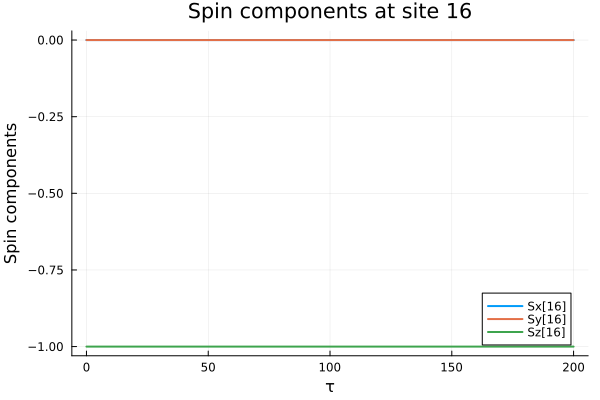

In [15]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays

# ----------------------------
# Parameters
# ----------------------------
Random.seed!(1234)        # reproducible
L = 100                  # chain length (L = number of sites)
J = 1.0                  # |J_x| = |J_y| = J_z = J
Jz = J
Δ = 0.5                  # discrete time step for sign flips (tau units)
Tfinal = 200.0           # final time (tau)
nsteps = Int(ceil(Tfinal / Δ))   # number of sign-steps
tspan = (0.0, Tfinal)

#Jx_steps = [rand() < 0.5 ? -1 : 1 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1 : 1 for _ in 1:nsteps]

Jx_steps = [1.0 for _ in 1:nsteps]  # for testing: constant +1
Jy_steps = [1.0 for _ in 1:nsteps]   # for testing: constant

# zero-order-hold helper: give Jx(t), Jy(t) for any time t
# clamp index to [1, nsteps]
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# ----------------------------
# Equations of motion
# ----------------------------
# state vector S is length 3L, arranged as columns: [S[:,1]; S[:,2]; ...] = vec(S_matrix)
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    # reshape into 3 x L
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    # current signs
    Jx_sign = sign_at_time(t, Jx_steps, Δ)
    Jy_sign = sign_at_time(t, Jy_steps, Δ)

    # loop through sites with periodic bc
    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        # tilde S for neighbors (weighted by current Jx(t), Jy(t), fixed Jz)
        tilde_m = @SVector [ Jx_sign * S[1, jm], Jy_sign * S[2, jm], Jz * S[3, jm] ]
        tilde_p = @SVector [ Jx_sign * S[1, jp], Jy_sign * S[2, jp], Jz * S[3, jp] ]

        local_field = tilde_m + tilde_p

        # cross product local_field × S_j with minus sign: dS_j = - local_field × S_j
        # (the formula in the prompt has dS_j/dτ = - (tilde_{j-1}+tilde_{j+1}) × S_j )
        Sj = S[:, j]
        dS_mat[:, j] .= -cross(local_field, Sj)
    end
end

# ----------------------------
# Initial condition (example: random normalized spins)
# ----------------------------
#S0 = randn(3, L)
N = L
S0 = zeros(3, N)
for i in 1:N
    if isodd(i)
        S0[:, i] = [0.0, 0.0, 1.0]   
    else
        S0[:, i] = [0.0, 0.0, -1.0]  
    end
end
for j in 1:L
    S0[:, j] ./= norm(S0[:, j])
end
S0_vec = vec(S0)

# pack parameters for the ODE function
p = (L, Jz, Jx_steps, Jy_steps, Δ)

# ----------------------------
# Solve
# ----------------------------
prob = ODEProblem(heisenberg_stochastic!, S0_vec, tspan, p)

# Choose solver and tolerances; saveat for output sampling
save_dt = 0.1
sol = solve(prob, Tsit5(), reltol=1e-7, abstol=1e-9, saveat=save_dt)

# ----------------------------
# Diagnostics & plotting
# ----------------------------
# pick a site to inspect
site = 16
S_site_t = [reshape(u, (3, L))[:, site] for u in sol.u]
Sx = [s[1] for s in S_site_t]
Sy = [s[2] for s in S_site_t]
Sz = [s[3] for s in S_site_t]

t = sol.t
plt1 = plot(t, Sx, label="Sx[$site]", lw=2)
plot!(t, Sy, label="Sy[$site]", lw=2)
plot!(t, Sz, label="Sz[$site]", lw=2)
xlabel!("τ")
ylabel!("Spin components")
title!("Spin components at site $site")

# display
plot(plt1)   # spin components plot

In [5]:
using Pkg
Pkg.add("StaticArrays")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.12/Project.toml`
  [90137ffa] + StaticArrays v1.9.15
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
